Setup stuff

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

data_frame = pd.read_csv("../data/all_fights.csv")


# drop weird stances
data_frame = data_frame[~data_frame["blue_stance"].isin(["Switch ", "Open Stance", "Unknown"])]
data_frame = data_frame[~data_frame["red_stance"].isin(["Switch ", "Open Stance", "Unknown"])]


# dropping reach diff over 40 (1 entry)
data_frame = data_frame[(data_frame["reach_diff"] > -40) | (data_frame["reach_diff"] < 40)]


# dropping Catch Weight from weight_class
data_frame = data_frame[~data_frame["weight_class"].isin(["Catch Weight"])]


# Round_diff - check this one a bit better, only 1 super outlier
data_frame = data_frame[(data_frame["rounds_diff"] > -100) | (data_frame["rounds_diff"] < 100)]
#print(data_frame["weight_class"].value_counts())


# ============
# Get all diffs
diff_features = data_frame.filter(regex=r'_diff').columns.to_list()

#Extra features
extra_features = ['gender', 'weight_class', 'red_stance', 'blue_stance']

# 2 feature sets one with odd and one without
features_with_odds = extra_features + diff_features
features_no_odds = [f for f in features_with_odds if f != 'odds_diff']

DATE = "2023-06-01"

#Target
y = (data_frame['red_winner'] == 't').astype(int)

#Split the data by date
train_mask = data_frame['fight_date'] <= DATE
test_mask = data_frame['fight_date'] > DATE

y_train = y[train_mask]
y_test = y[test_mask]

#Feature set without odds
X_train_no_odds = data_frame.loc[train_mask, features_no_odds]
X_test_no_odds = data_frame.loc[test_mask, features_no_odds]

#Feature with odds
X_train_with_odds = data_frame.loc[train_mask, features_with_odds]
X_test_with_odds = data_frame.loc[test_mask, features_with_odds]


#### Trying models

0:	learn: 0.5890967	test: 0.6039604	best: 0.6039604 (0)	total: 5.44ms	remaining: 2.71s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.603960396
bestIteration = 0

Shrink model to first 1 iterations.
0.6039603960396039
              precision    recall  f1-score   support

           f       0.57      0.45      0.50       673
           t       0.62      0.73      0.67       842

    accuracy                           0.60      1515
   macro avg       0.60      0.59      0.59      1515
weighted avg       0.60      0.60      0.60      1515

                 Feature Id  Importances
0                  age_diff    94.750684
1                    gender     2.671323
2               rounds_diff     2.577993
3              weight_class     0.000000
4                red_stance     0.000000
5               blue_stance     0.000000
6                reach_diff     0.000000
7               height_diff     0.000000
8                 wins_diff     0.000000
9               losses_d

### CHAT PLOT - weight_class distribution after split

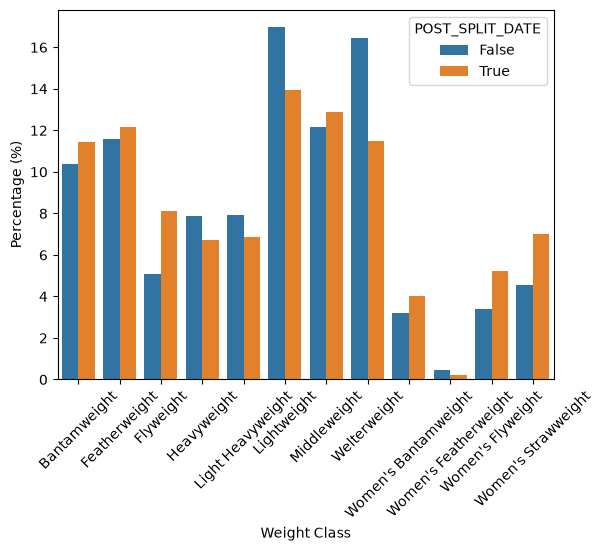

In [11]:
data_frame["POST_SPLIT_DATE"] = data_frame["fight_date"] > SPLIT_DATE

percentage_df = (
    data_frame
    .groupby(["POST_SPLIT_DATE", "weight_class"])
    .size()
    .groupby(level=0)
    .transform(lambda x: x / x.sum() * 100)
    .reset_index(name="percentage")
)

sns.barplot(
    data=percentage_df,
    x="weight_class",
    y="percentage",
    hue="POST_SPLIT_DATE"
)

plt.ylabel("Percentage (%)")
plt.xlabel("Weight Class")
plt.xticks(rotation=45)
plt.show()

### random test stuff

In [ ]:
#NOTE: random tests

##NOTE: combining fight stances - does not needed
#data_frame["stance_diff"] = data_frame["red_stance"] + "-" + data_frame["blue_stance"]
#stance_diff = data_frame['stance_diff'].unique()
#print(stance_diff)

#blue_stance = data_frame['blue_stance'].unique()
#gender = data_frame['gender'].unique()
#weight_class = data_frame['weight_class'].unique()
#print(weight_class)
#print(blue_stance)

#diff_only_df = diff_only_df.drop((diff_only_df["blue_stance"] == "Unknown")) 
#| (data_frame["blue_stance"] == "Switch ") | (data_frame["blue_stance"] == "Open Stance ")]

#for i in weight_class:
#    print(i)

#focked = data_frame[(data_frame["blue_stance"] == "Unknown") | (data_frame["blue_stance"] == "Switch ")]

#focked = data_frame[(data_frame["weight_class"] == "Catch Weight")]
#print(focked)
#print(focked.shape)

#print(data_frame[data_frame["blue_stance"] == "Unknown"])


#NOTE STUFF FROM FIRST CELL
#y_training_df.info()

#print(x_training_df.head)

""" data_count = data_frame.shape[0]
training_count = data_frame_training.shape[0]
test_count = data_frame_testing.shape[0]

print(f"Data is split on fights before {SPLIT_DATE} and after {SPLIT_DATE}")
print("Training Data")
print(f"Before {SPLIT_DATE} | size : {training_count} | Percent of total : {((training_count / data_count)*100):.2f}%")
print("Test Data")
print(f"After  {SPLIT_DATE} | size : {test_count} | Percent of total : {((test_count / data_count)*100):.1f}%") """



# splitting data
# find date of
""" x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    stratify=y,
    random_state=26
) """

### NON-diff categories that we might want to keep
red_winner


#### total classes
14 * 2 * 3 * 8 = 

#### weight_class
drop catch weight?

Flyweight
Welterweight
Heavyweight
Featherweight
Light Heavyweight
Catch Weight // dropped
Lightweight
Bantamweight
Women's Strawweight
Women's Flyweight
Middleweight
Women's Bantamweight
Women's Featherweight
total 14

#### gender
'MALE'
'FEMALE'
total 2

#### blue_ and red_ stance

drop 'Switch ' 'Open Stance' 'Unknown'

orth - orth
orth - south
orth - switch
south - south
south - switch
switch - switch

total 6

#### blue_ and red_ age
18-23 
24-27 
28-33
33+

total 8

In [ ]:
#focked = data_frame[(data_frame["reach_diff"] < -30) | (data_frame["reach_diff"] > 30)]
#print(focked)
#print(focked.shape)


## Plot tests

In [ ]:
""" sns.countplot(
    data=data_frame,
    y='red_stance',
    x='blue_stance',
    # order=df['category'].value_counts().index
) """

sns.catplot(
    data=data_frame,
    x="red_stance",
    #y="red_winner",
    col="blue_stance",
    kind="count",
    col_wrap=3
)

""" sns.catplot(
    data=df_analysis,
    x="pclass",
    y="survived",
    col="who",
    kind="bar"
) """

plt.show()

#### How to split the data


#### How to split the data into training / test set?


#### What is the benchmark you will compare your model with?


#### Which models have a good chance of working well on this data set?


#### What preprocessing needs to be done to use these models?


#### How to set the hyperparameters of these models and/or which range of values for the hyperparameters should be tried?


#### How to evaluate the different models to decide on the best one?



In [ ]:
""" # TRAINING
train_df = pd.DataFrame({
    "target": y_train,
    "data": x_train
})

train_df["class"] = train_df["target"].map(
    lambda x: newsgroups.target_names[x]
)

train_class_count = train_df['target'].value_counts().sort_index()
train_result = pd.DataFrame({
    "class": newsgroups.target_names,
    "count": train_class_count,
    "share": train_class_count / len(train_df) * 100
})
#print(train_result)
#print("total count: ", train_result["count"].sum())

# TEST
test_df = pd.DataFrame({
    "target": y_test,
    "data": x_test
})

test_df["class"] = test_df["target"].map(
    lambda x: newsgroups.target_names[x]
)

test_class_count = test_df['target'].value_counts().sort_index()
test_result = pd.DataFrame({
    "class": newsgroups.target_names,
    "count": test_class_count,
    "share": test_class_count / len(test_df) * 100
})

#print(test_result)
#print("total count: ", test_result["count"].sum())

train_result["dataset"] = "Train"
test_result["dataset"] = "Test"
combined = pd.concat([train_result, test_result])

sns.barplot(
    data=combined,
    x="share",
    y="class",
    hue="dataset"
)

plt.xlabel("Percentage")
plt.ylabel("Class")

plt.show() """